<a href="https://colab.research.google.com/github/andashevabegimai/facelockk/blob/main/Imageprocessing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install -r requirements.txt

In [ ]:
def calculate_psnr(img1, img2):
    arr1 = np.array(img1).astype(float)
    arr2 = np.array(img2).astype(float)

    mse = np.mean((arr1 - arr2) ** 2)

    if mse == 0:
        return 100

    return 20 * np.log10(255.0 / np.sqrt(mse))


def load_image(path):
    return Image.open(path).convert("RGB")


def show_images(images, titles, figsize=(12, 6)):
    fig, ax = plt.subplots(1, len(images), figsize=figsize)

    if len(images) == 1:
        ax = [ax]

    for i in range(len(images)):
        ax[i].imshow(images[i])
        ax[i].set_title(titles[i])
        ax[i].axis("off")

    plt.tight_layout()
    plt.show()


def run_edit(input_path, prompt, output_path):
    cmd = (
        f'python edit.py '
        f'--input_path="{input_path}" '
        f'--prompt="{prompt}" '
        f'--output_path="{output_path}"'
    )

    print(cmd)
    os.system(cmd)

In [ ]:
%cd /content
!rm -rf FaceLock
!git clone https://github.com/taco-group/FaceLock.git

/content
Cloning into 'FaceLock'...
remote: Enumerating objects: 37, done.
remote: Counting objects: 100% (37/37), done.
remote: Compressing objects: 100% (24/24), done.
remote: Total 37 (delta 13), reused 30 (delta 10), pack-reused 0 (from 0)
Receiving objects: 100% (37/37), 688.25 KiB | 28.68 MiB/s, done.
Resolving deltas: 100% (13/13), done.
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 130.7/130.7 kB 10.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.5/8.5 MB 109.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 104.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 401.2/401.2 kB 33.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 190.9/190.9 kB 21.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 280.0/280.0 kB 28.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 762.2/762.2 kB 57.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 277.0/277.0 MB 5.1 MB/s eta 0:00:00
   ━━━━━━━━━

In [ ]:
from google.colab import files
import os

print("Upload your photo:")
uploaded = files.upload()

for filename in uploaded.keys():
    os.rename(filename, "my_face.jpg")
    print("Success! File renamed to my_face.jpg")

Upload your photo:


Saving photo_2026-04-21_00-43-28.jpg to photo_2026-04-21_00-43-28.jpg
Success! File renamed to my_face.jpg


In [ ]:
%cd /content/FaceLock
import os
from google.colab import userdata
from PIL import Image

# Access setup
os.environ['HF_HOME'] = '/content/hf_cache'
os.environ['HUGGINGFACE_HUB_TOKEN'] = userdata.get('HF_TOKEN')
os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True"

# Preparation (compress to 512x512)
img = Image.open("/content/my_face.jpg").convert('RGB').resize((512, 512), Image.Resampling.LANCZOS)
img.save("my_face_512.jpg")


/content/FaceLock


In [ ]:
# Run defense
!python defend.py --input_path="my_face_512.jpg" --defend_method="facelock" --attack_budget=0.08 --output_path="adv_my_face_512.png"

/usr/local/lib/python3.12/dist-packages/huggingface_hub/file_download.py:1132: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
model_index.json: 100% 616/616 [00:00<00:00, 5.83MB/s]
Fetching 13 files:   0% 0/13 [00:00<?, ?it/s]
tokenizer_config.json: 100% 806/806 [00:00<00:00, 1.33MB/s]

scheduler_config.json: 100% 569/569 [00:00<00:00, 5.71MB/s]

config.json: 100% 617/617 [00:00<00:00, 6.03MB/s]

special_tokens_map.json: 100% 472/472 [00:00<00:00, 4.70MB/s]


merges.txt: 0.00B [00:00, ?B/s]
vocab.json: 0.00B [00:00, ?B/s]


merges.txt: 525kB [00:00, 49.3MB/s]


preprocessor_config.json: 100% 518/518 [00:00<00:00, 4.29MB/s]
vocab.json: 1.06MB [00:00, 80.9MB/s]



model.safetensors:   6% 31.5M/492M [00:00<00:01, 247MB/s]
config.json: 1.02kB [00:00, 5.66MB/s]

diffusion_pytorch_model.safetensors:   0% 0.00/3.44G [00:00<?, ?B/s]


mod

In [ ]:
# Run defense
!python defend.py --input_path="my_face_512.jpg" --defend_method="facelock" --attack_budget=0.08 --output_path="adv_my_face_512.png"

/usr/local/lib/python3.12/dist-packages/huggingface_hub/file_download.py:1132: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
Loading pipeline components...: 100% 6/6 [00:17<00:00,  2.90s/it]
/usr/local/lib/python3.12/dist-packages/timm/models/layers/__init__.py:49: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)
Loaded ViT model with KPRPE
compatible keys in state_dict 283 / 283
Check


<All keys matched successfully>
Loaded pretrained model from pretrained_model/model.pt
/usr/local/lib/python3.12/dist-packages/huggingface_hub/file_download.py:1194: UserWarning: `local_dir_use_symlinks` parameter is deprecated and will be ignored. The process to download files to a local folder ha

In [ ]:
%cd /content/FaceLock
!python edit.py --input_path="adv_my_face_512.png" --prompt="a professional corporate headshot, studio lighting" --output_path="edited_adv_face.png"

/content/FaceLock
/usr/local/lib/python3.12/dist-packages/huggingface_hub/file_download.py:1132: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
Loading pipeline components...: 100% 6/6 [00:15<00:00,  2.52s/it]
100% 50/50 [00:10<00:00,  4.69it/s]


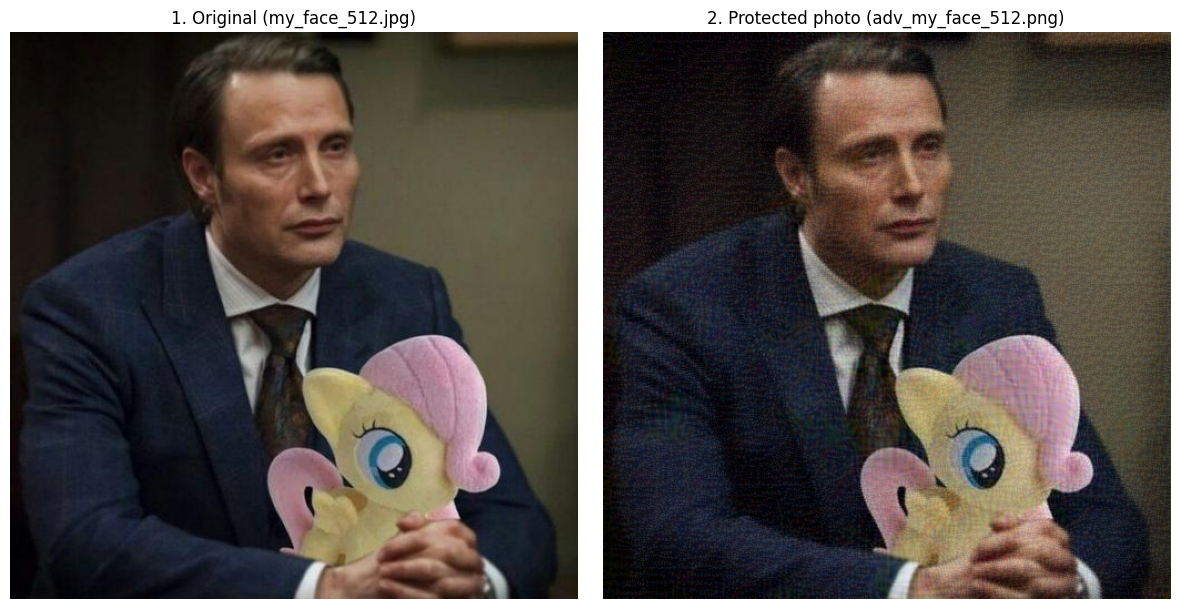

In [ ]:
img_orig = load_image('my_face_512.jpg')
img_adv = load_image('adv_my_face_512.png')

show_images(
    [img_orig, img_adv],
    [
        "1. Original (my_face_512.jpg)",
        "2. Protected photo (adv_my_face_512.png)"
    ]
)

In [ ]:
%cd /content/FaceLock

run_edit(
    "adv_my_face_512.png",
    "a professional corporate headshot, studio lighting",
    "edited_adv_face.png"
)

/content/FaceLock
python edit.py --input_path="adv_my_face_512.png" --prompt="a professional corporate headshot, studio lighting" --output_path="edited_adv_face.png"


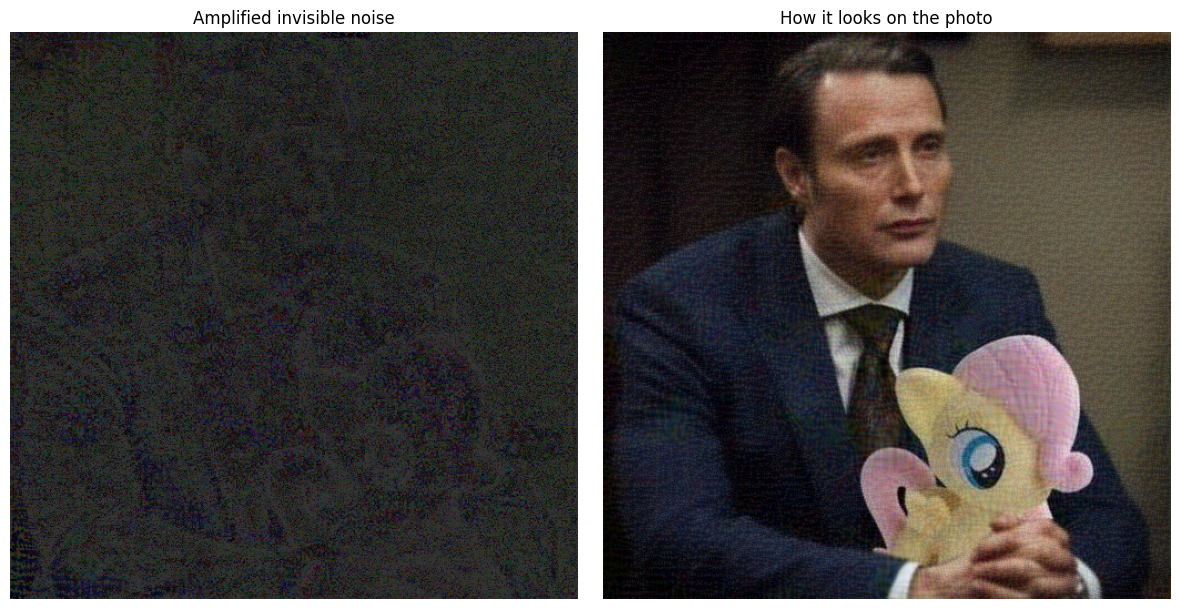

In [ ]:

# 1. Load images
orig = load_image('my_face_512.jpg')
adv = load_image('adv_my_face_512.png')

# 2. Convert to numbers (arrays)
orig_arr = np.array(orig).astype(float)
adv_arr = np.array(adv).astype(float)

# 3. Subtract the original from the protected photo
# Take the absolute difference so the noise is a positive number
diff = np.abs(adv_arr - orig_arr)

# 4. Amplify the noise by 10 times to make it visible
diff_amplified = diff * 5
diff_amplified = np.clip(diff_amplified, 0, 255).astype(np.uint8)

# 5. Plot the result using the helper function
diff_amplified_img = Image.fromarray(diff_amplified)

show_images(
    [diff_amplified_img, adv],
    ["Amplified invisible noise", "How it looks on the photo"]
)

/content/FaceLock
/usr/local/lib/python3.12/dist-packages/huggingface_hub/file_download.py:1132: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
Loading pipeline components...: 100% 6/6 [00:04<00:00,  1.29it/s]
100% 50/50 [00:10<00:00,  4.59it/s]


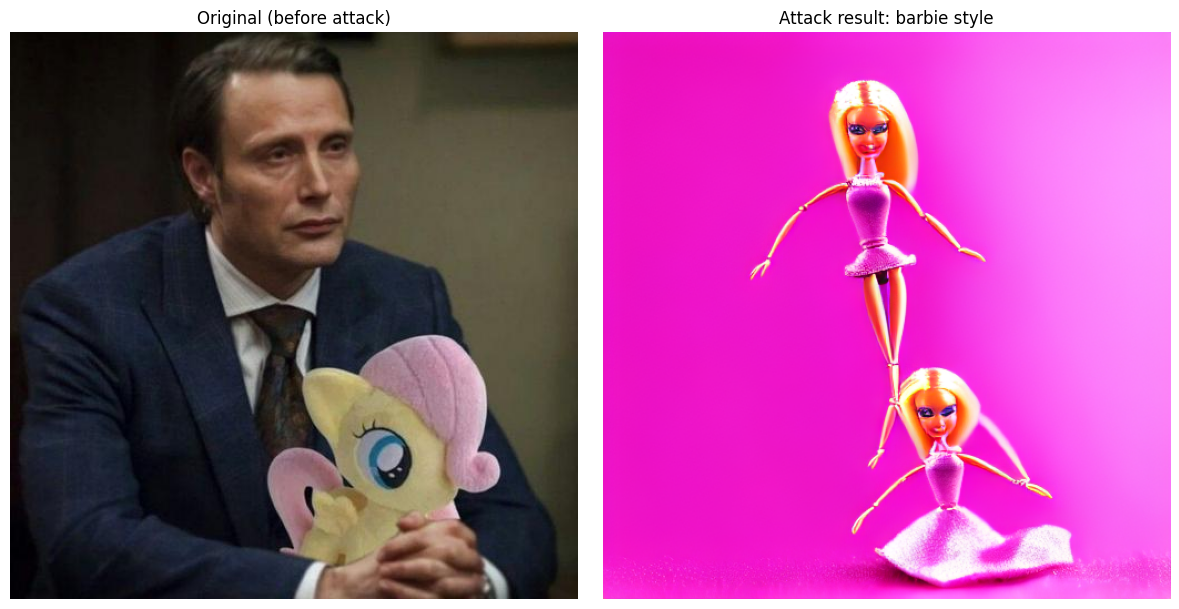

Attack completed! Prompt: barbie style


In [ ]:
%cd /content/FaceLock

# 1. Attack parameters
my_custom_prompt = "barbie style"

# 2. Performing the attack
!python edit.py --input_path="adv_my_face_512.png" --prompt="{my_custom_prompt}" --output_path="edited_adv_face.png"

# 3. Displaying the result immediately
img_orig = load_image('my_face_512.jpg')
img_edited = load_image('edited_adv_face.png')

show_images(
    [img_orig, img_edited],
    [
        "Original (before attack)",
        f"Attack result: {my_custom_prompt}"
    ]
)

print(f"Attack completed! Prompt: {my_custom_prompt}")

/content/FaceLock
/usr/local/lib/python3.12/dist-packages/huggingface_hub/file_download.py:1132: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
Loading pipeline components...: 100% 6/6 [00:04<00:00,  1.22it/s]
100% 50/50 [00:11<00:00,  4.53it/s]
/usr/local/lib/python3.12/dist-packages/huggingface_hub/file_download.py:1132: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
Loading pipeline components...: 100% 6/6 [00:03<00:00,  1.61it/s]
100% 50/50 [00:11<00:00,  4.50it/s]


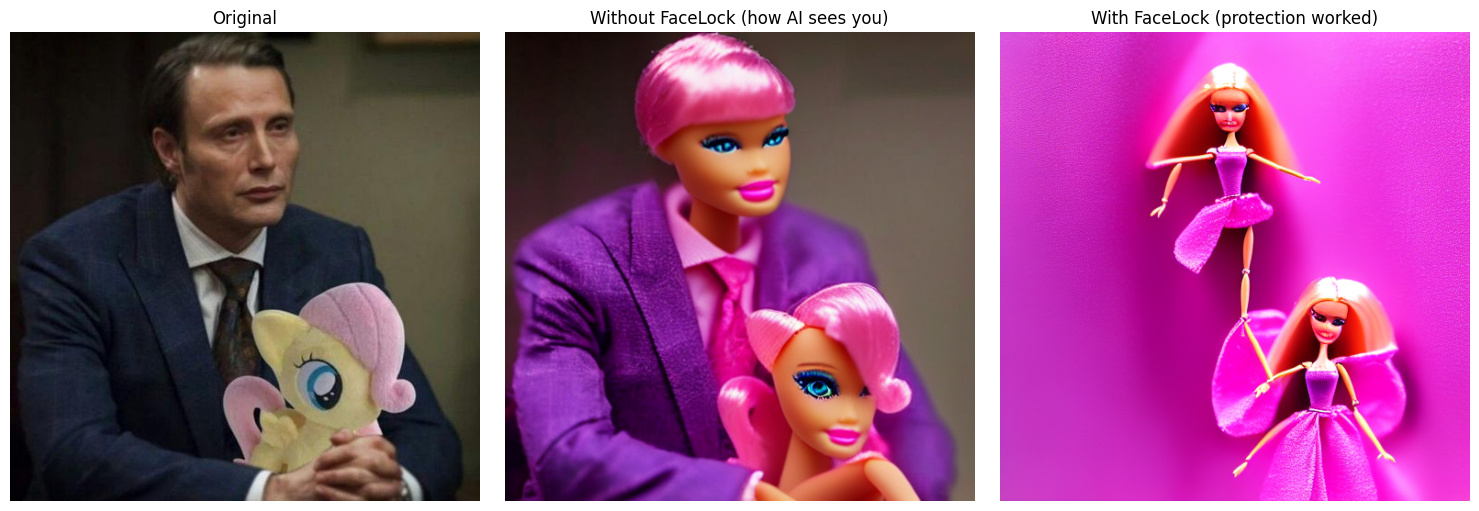

In [ ]:
%cd /content/FaceLock

my_custom_prompt = "barbie style"

# 2. Performing the attack
!python edit.py --input_path="adv_my_face_512.png" --prompt="{my_custom_prompt}" --output_path="edited_adv_face.png"

# 2. ATTACK WITHOUT PROTECTION (using original file)
!python edit.py --input_path="my_face_512.jpg" --prompt="{my_custom_prompt}" --output_path="edited_NO_protection.png"

# 3. Visualization: Original vs Result without protection vs Result with FaceLock
img_orig = load_image('my_face_512.jpg')
img_no_prot = load_image('edited_NO_protection.png')
img_with_prot = load_image('edited_adv_face.png')

show_images(
    [img_orig, img_no_prot, img_with_prot],
    [
        "Original",
        "Without FaceLock (how AI sees you)",
        "With FaceLock (protection worked)"
    ],
    figsize=(15, 5)
)

In [ ]:
# from huggingface_hub import InferenceClient
# from google.colab import userdata
# import base64
# from io import BytesIO

# # 1. Visualization
# img_orig = load_image('my_face_512.jpg')
# img_edited = load_image('edited_adv_face.png')

# fig, ax = plt.subplots(1, 2, figsize=(12, 6))
# ax[0].imshow(img_orig); ax[0].set_title("Original (before attack)"); ax[0].axis("off")
# ax[1].imshow(img_edited); ax[1].set_title("Generation result (after FaceLock)"); ax[1].axis("off")
# plt.tight_layout()
# plt.show()

# # 2. Expert analysis (VIPGuard logic)
# def image_to_base64(img_path):
#     img = Image.open(img_path)
#     buffer = BytesIO()
#     img.save(buffer, format="JPEG")
#     return base64.b64encode(buffer.getvalue()).decode("utf-8")

# client = InferenceClient(token=userdata.get('HF_TOKEN'))
# prompt = "Analyze these two images. Compare the eyes, jaw, and nose. Is the identity of the person on the second image destroyed by FaceLock? Answer professionally."

# messages = [{
#     "role": "user",
#     "content": [
#         {"type": "text", "text": prompt},
#         {"type": "image_url", "image_url": {"url": f"data:image/jpeg;base64,{image_to_base64('my_face_512.jpg')}"}},
#         {"type": "image_url", "image_url": {"url": f"data:image/jpeg;base64,{image_to_base64('edited_adv_face.png')}"}},
#     ],
# }]

# print("\n" + "="*30)
# print("VIPGUARD EXPERT ANALYSIS REPORT")
# print("="*30 + "\n")

# response = client.chat_completion(
#     model="Qwen/Qwen2.5-VL-72B-Instruct",
#     messages=messages,
#     max_tokens=1500)

# print(response.choices[0].message.content)

/content/FaceLock


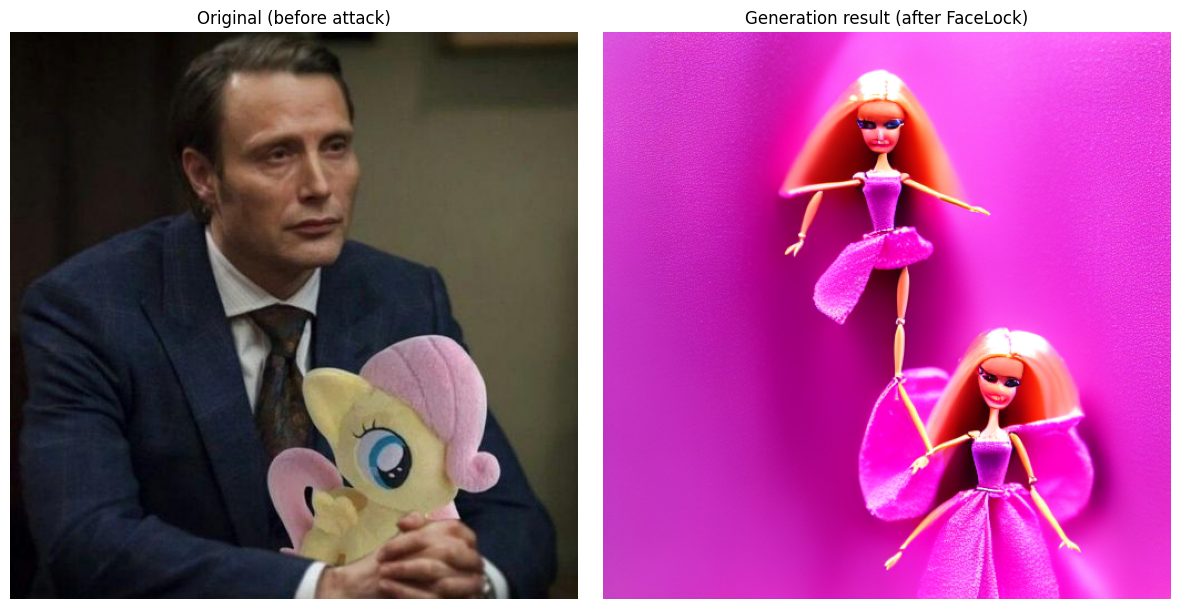


Running expert analysis...

--- EXPERT REPORT ---
As a biometric security expert, I will conduct a comparative analysis of the structural features presented in both images to determine biometric identity.

**Image 1 Analysis (Human Subject):**

This image clearly depicts a human male. His facial features are highly distinct and suitable for robust biometric identification.

*   **Eyes:** Deep-set, almond-shaped with clear eyelids, discernible irises and pupils, and a prominent brow ridge. The inter-ocular distance, eye shape, and position are unique biometric markers.
*   **Cheekbones:** High and well-defined, contributing to a distinctive angularity in the mid-face. These provide significant anthropometric data.
*   **Jaw:** Strong, clearly articulated jawline with a well-defined angle and chin. This is a critical feature for facial recognition algorithms.
*   **Nose:** Relatively long and straight, with a distinct bridge, tip, and nostrils. Its width, length, and projection are uniq

In [ ]:
%cd /content/FaceLock

# 1. First, visualization (photos side by side)
img_orig = Image.open('my_face_512.jpg')
img_edited = Image.open('edited_adv_face.png')

fig, ax = plt.subplots(1, 2, figsize=(12, 6))
ax[0].imshow(img_orig)
ax[0].set_title("Original (before attack)")
ax[0].axis("off")

ax[1].imshow(img_edited)
ax[1].set_title("Generation result (after FaceLock)")
ax[1].axis("off")
plt.tight_layout()
plt.show()

# 2. Now, expert analysis (VIPGuard-style)
from google import genai
from google.colab import userdata

client = genai.Client(api_key=userdata.get('GEMINI_API_KEY'))

prompt = """
You are a biometric security expert.
Analyze these two images. Compare the structural features of the face (eyes, cheekbones, jaw, nose).
Explain if there are differences in biometric identity.
Conclude: has the person's identity in the second photo been successfully destroyed as a result of generative editing?
"""

print("\nRunning expert analysis...\n")

response = client.models.generate_content(
    model='gemini-2.5-flash',
    contents=[prompt, img_orig, img_edited]
)

print("--- EXPERT REPORT ---")
print(response.text)

In [ ]:
from deepface import DeepFace


ModuleNotFoundError: No module named 'deepface'

In [ ]:
%cd /content/FaceLock

my_custom_prompt = "make the person wear a glasses"

# 2. Performing the attack
!python edit.py --input_path="adv_my_face_512.png" --prompt="{my_custom_prompt}" --output_path="edited_adv_face.png"

# 2. ATTACK WITHOUT PROTECTION (using original file)
!python edit.py --input_path="my_face_512.jpg" --prompt="{my_custom_prompt}" --output_path="edited_NO_protection.png"

# 3. Visualization: Original vs Result without protection vs Result with FaceLock
img_orig = load_image('my_face_512.jpg')
img_no_prot = load_image('edited_NO_protection.png')
img_with_prot = load_image('edited_adv_face.png')

show_images(
    [img_orig, img_no_prot, img_with_prot],
    [
        "Original",
        "Without FaceLock (how AI sees you)",
        "With FaceLock (protection worked)"
    ],
    figsize=(15, 5)
)

In [ ]:
from insightface.app import FaceAnalysis
from scipy.spatial.distance import cosine

print("[SYSTEM]: Initializing ArcFace biometric model (InsightFace)...")
# 1. Load the face recognition model (buffalo_l contains ArcFace)
app = FaceAnalysis(name='buffalo_l', providers=['CUDAExecutionProvider', 'CPUExecutionProvider'])
app.prepare(ctx_id=0, det_size=(640, 640)) # ctx_id=0 means using GPU

# 2. Load images (OpenCV reads them in BGR format, which is needed for InsightFace)
img_orig = cv2.imread('my_face_512.jpg')
img_edited = cv2.imread('edited_NO_protection.png')

# =========================================================
# VISUALIZATION BLOCK: Convert BGR (OpenCV) to RGB (Matplotlib)
img_orig_rgb = cv2.cvtColor(img_orig, cv2.COLOR_BGR2RGB)
img_edited_rgb = cv2.cvtColor(img_edited, cv2.COLOR_BGR2RGB)

fig, ax = plt.subplots(1, 2, figsize=(12, 6))
ax[0].imshow(img_orig_rgb)
ax[0].set_title("1. Original Image")
ax[0].axis("off")

ax[1].imshow(img_edited_rgb)
ax[1].set_title("2. Edited (NO protection)")
ax[1].axis("off")

plt.tight_layout()
plt.show() # This command will draw the images on the screen
# =========================================================

# 3. Find faces and extract biometric vectors (embeddings)
faces_orig = app.get(img_orig)
faces_edited = app.get(img_edited)

if len(faces_orig) == 0 or len(faces_edited) == 0:
    print("Error: Face not found in one of the photos!")
else:
    # Take the vector of the first detected face
    emb_orig = faces_orig[0].embedding
    emb_edited = faces_edited[0].embedding

    # 4. Calculate Cosine Distance
    # Cosine distance = 1 - Cosine Similarity
    distance = cosine(emb_orig, emb_edited)

    # Standard threshold for ArcFace model: if distance is greater than 0.68, they are different people
    threshold = 0.68
    is_same_person = distance < threshold

    # 5. Pretty print the report for the commission
    print("\n" + "="*50)
    print("FACELOCK VERIFICATION REPORT")
    print("="*50)
    print(f"Verified Identity : {is_same_person}")
    print(f"Distance          : {distance:.4f}")
    print(f"Threshold         : {threshold:.4f}")
    print(f"Model             : ArcFace")
    print(f"Metric            : cosine")
    print("="*50)

    if not is_same_person:
        print("✓ Face recognition failed.")
        print("✓ Identity protection appears successful.")
    else:
        print("⚠ Face recognition still succeeds. Protection failed.")

In [ ]:


print("[SYSTEM]: Initializing ArcFace biometric model (InsightFace)...")
# 1. Load the face recognition model (buffalo_l contains ArcFace)
app = FaceAnalysis(name='buffalo_l', providers=['CUDAExecutionProvider', 'CPUExecutionProvider'])
app.prepare(ctx_id=0, det_size=(640, 640)) # ctx_id=0 means using GPU

# 2. Load images (OpenCV reads them in BGR format, which is needed for InsightFace)
img_orig = cv2.imread('my_face_512.jpg')
img_edited = cv2.imread('edited_adv_face.png')

# =========================================================
# VISUALIZATION BLOCK: Convert BGR (OpenCV) to RGB (Matplotlib)
img_orig_rgb = cv2.cvtColor(img_orig, cv2.COLOR_BGR2RGB)
img_edited_rgb = cv2.cvtColor(img_edited, cv2.COLOR_BGR2RGB)

fig, ax = plt.subplots(1, 2, figsize=(12, 6))
ax[0].imshow(img_orig_rgb)
ax[0].set_title("1. Original Image")
ax[0].axis("off")

ax[1].imshow(img_edited_rgb)
ax[1].set_title("2. Edited (with FaceLock protection)")
ax[1].axis("off")

plt.tight_layout()
plt.show() # This command will draw the images on the screen
# =========================================================

# 3. Find faces and extract biometric vectors (embeddings)
faces_orig = app.get(img_orig)
faces_edited = app.get(img_edited)

if len(faces_orig) == 0 or len(faces_edited) == 0:
    print("Error: Face not found in one of the photos!")
else:
    # Take the vector of the first detected face
    emb_orig = faces_orig[0].embedding
    emb_edited = faces_edited[0].embedding

    # 4. Calculate Cosine Distance
    # Cosine distance = 1 - Cosine Similarity
    distance = cosine(emb_orig, emb_edited)

    # Standard threshold for ArcFace model: if distance is greater than 0.68, they are different people
    threshold = 0.68
    is_same_person = distance < threshold

    # 5. Pretty print the report for the commission
    print("\n" + "="*50)
    print("FACELOCK VERIFICATION REPORT")
    print("="*50)
    print(f"Verified Identity : {is_same_person}")
    print(f"Distance          : {distance:.4f}")
    print(f"Threshold         : {threshold:.4f}")
    print(f"Model             : ArcFace")
    print(f"Metric            : cosine")
    print("="*50)

    if not is_same_person:
        print("✓ Face recognition failed.")
        print("✓ Identity protection appears successful.")
    else:
        print("⚠ Face recognition still succeeds. Protection failed.")

In [ ]:
# %cd /content/FaceLock

# my_custom_prompt = "make him wear glasses"

# # 2. Performing the attack
# !python edit.py --input_path="adv_my_face_512.png" --prompt="{my_custom_prompt}" --output_path="edited_adv_face.png"

# # 2. ATTACK WITHOUT PROTECTION (using original file)
# !python edit.py --input_path="my_face_512.jpg" --prompt="{my_custom_prompt}" --output_path="edited_NO_protection.png"

# # 3. Visualization: Original vs Result without protection vs Result with FaceLock
# img_orig = load_image('my_face_512.jpg')
# img_no_prot = load_image('edited_NO_protection.png')
# img_with_prot = load_image('edited_adv_face.png')

# show_images(
#     [img_orig, img_no_prot, img_with_prot],
#     [
#         "Original",
#         "Without FaceLock (how AI sees you)",
#         "With FaceLock (protection worked)"
#     ],
#     figsize=(15, 5)
# )